In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

In [ ]:
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
BASE_PATH = r'D:\SSCode\DST\EDW'

In [3]:
try:
    if 'df' not in locals():
        print("🔄 원본 데이터를 다시 읽어옵니다...")
        orders = pd.read_csv(os.path.join(BASE_PATH, 'olist_orders_dataset.csv'))
        items = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_items_dataset.csv'))
        customers = pd.read_csv(os.path.join(BASE_PATH, 'olist_customers_dataset.csv'))
        sellers = pd.read_csv(os.path.join(BASE_PATH, 'olist_sellers_dataset.csv'))
        reviews = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_reviews_dataset.csv'))
        geo = pd.read_csv(os.path.join(BASE_PATH, 'olist_geolocation_dataset.csv'))
        products = pd.read_csv(os.path.join(BASE_PATH, 'olist_products_dataset.csv'))
        trans = pd.read_csv(os.path.join(BASE_PATH, 'product_category_name_translation.csv'))

        df = orders.merge(items, on='order_id')
        df = df.merge(customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id')
        df = df.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id')
        df = df.merge(reviews[['order_id', 'review_score']], on='order_id')
        products = products.merge(trans, on='product_category_name', how='left')
        df = df.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
        
        # 거리 계산
        geo_avg = geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()
        df = df.merge(geo_avg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'c_lat', 'geolocation_lng': 'c_lng'})
        df = df.merge(geo_avg, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 's_lat', 'geolocation_lng': 's_lng'})

        R = 6371
        phi1, phi2 = np.radians(df['c_lat']), np.radians(df['s_lat'])
        dphi = np.radians(df['s_lat'] - df['c_lat'])
        dlambda = np.radians(df['s_lng'] - df['c_lng'])
        a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2) * np.sin(dlambda/2)**2
        df['distance_km'] = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

except Exception as e:
    pass

🔄 원본 데이터를 다시 읽어옵니다...


In [4]:
# ------------------------------------------------------------------
# [핵심 수정] 제품별이 아니라 '카테고리별'로 집계합니다.
# ------------------------------------------------------------------
cat_stats = df.groupby('product_category_name_english').agg({
    'order_id': 'count',       # 총 판매량
    'review_score': 'mean',    # 평균 평점
    'distance_km': 'mean',     # 평균 배송 거리
    'price': 'mean'            # 평균 객단가
}).reset_index()

cat_stats.columns = ['Category', 'Volume', 'Score', 'Distance', 'Price']

# 전체 카테고리 평균 거리 (기준점)
avg_dist_total = cat_stats['Distance'].mean()

In [5]:
# ------------------------------------------------------------------
# 전략별 카테고리 선정 (조건을 카테고리 평균에 맞게 조정)
# ------------------------------------------------------------------

# [Hero] 장거리 전문 카테고리
# 조건: 평균보다 멀리 가고(Distance > avg), 평점도 준수(Score >= 4.0)한 곳
hero_cat_5 = cat_stats[
    (cat_stats['Distance'] > avg_dist_total) & 
    (cat_stats['Score'] >= 4.0)
].sort_values(by='Volume', ascending=False).head(5)

# [Cash Cow] 근거리 알짜 카테고리
# 조건: 평균보다 가깝고(Distance < avg), 판매량이 많은 곳
cash_cow_cat_5 = cat_stats[
    (cat_stats['Distance'] <= avg_dist_total)
].sort_values(by='Volume', ascending=False).head(5)

print(f"✅ '카테고리 중심' 분석 준비 완료!")
print(f" - 전체 평균 배송 거리: {int(avg_dist_total)}km")
print(f" - Hero 카테고리: {hero_cat_5['Category'].tolist()}")
print(f" - Cash Cow 카테고리: {cash_cow_cat_5['Category'].tolist()}")

✅ '카테고리 중심' 분석 준비 완료!
 - 전체 평균 배송 거리: 587km
 - Hero 카테고리: ['health_beauty', 'sports_leisure', 'watches_gifts', 'garden_tools', 'auto']
 - Cash Cow 카테고리: ['bed_bath_table', 'furniture_decor', 'housewares', 'toys', 'perfumery']



🚀 [Hero] 멀리 팔리는 장거리 효자 카테고리 TOP 5
      Category  Volume   Distance    Score      Price
 health_beauty    9616 664.994165 4.142575 129.957925
sports_leisure    8623 597.196718 4.107619 114.310473
 watches_gifts    5927 641.881677 4.019065 201.052384
  garden_tools    4318 651.641739 4.042612 111.256135
          auto    4204 621.037407 4.064700 139.262129
------------------------------------------------------------



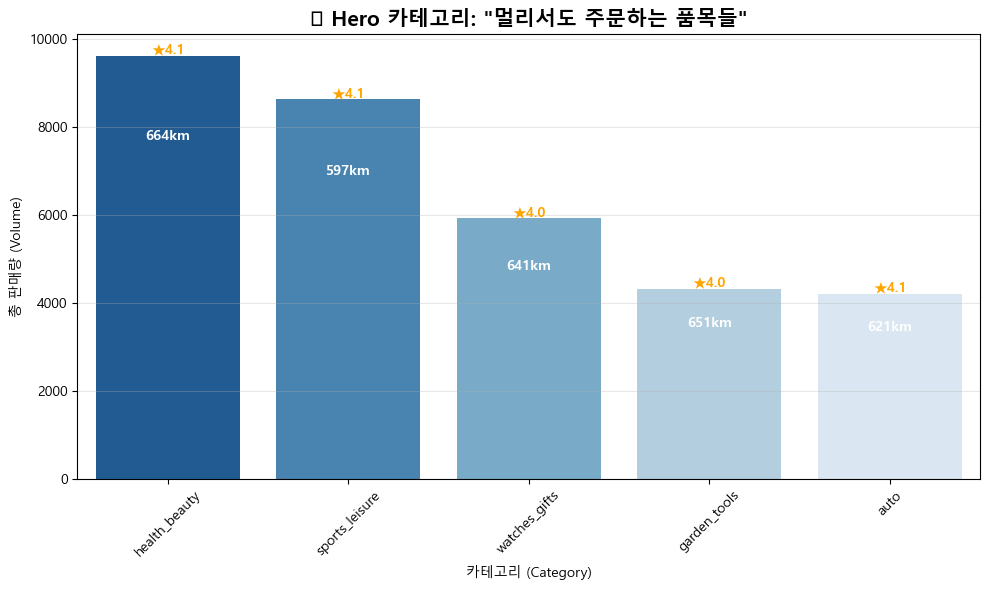

In [6]:
# === Hero (장거리) 카테고리 TOP 5 ===

# 1. 상세 표 출력 (가격 정보 포함)
print("\n" + "="*60)
print(f"🚀 [Hero] 멀리 팔리는 장거리 효자 카테고리 TOP 5")
print("="*60)
print(hero_cat_5[['Category', 'Volume', 'Distance', 'Score', 'Price']].to_string(index=False))
print("-" * 60 + "\n")

# 2. 시각화
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=hero_cat_5, x='Category', y='Volume', palette='Blues_r', ax=ax)

# 라벨링 (거리 + 평점 표시)
for i, p in enumerate(ax.patches):
    if i < len(hero_cat_5):
        height = p.get_height()
        dist = hero_cat_5['Distance'].iloc[i]
        score = hero_cat_5['Score'].iloc[i]
        
        # 막대 위: 평점 (별점 느낌)
        ax.text(p.get_x() + p.get_width()/2., height + 50, f"★{score:.1f}", 
                ha="center", fontsize=10, fontweight='bold', color='orange')
        
        # 막대 안: 거리 (흰색)
        ax.text(p.get_x() + p.get_width()/2., height - (height*0.2), f"{int(dist)}km", 
                ha="center", fontsize=10, fontweight='bold', color='white')

ax.set_title('🚀 Hero 카테고리: "멀리서도 주문하는 품목들"', fontsize=15, fontweight='bold')
ax.set_ylabel('총 판매량 (Volume)')
ax.set_xlabel('카테고리 (Category)')
ax.tick_params(axis='x', rotation=45) # 이름 길어질까봐 기울임
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


💰 [Cash Cow] 가까워서 배송비 아끼는 효자 카테고리 TOP 5
       Category  Volume   Distance    Score      Price
 bed_bath_table   11109 509.666243 3.896030  93.448639
furniture_decor    8311 561.770190 3.902539  87.624269
     housewares    6924 495.373214 4.055604  90.751769
           toys    4055 561.750070 4.161282 117.056059
      perfumery    3406 572.258531 4.160599 116.622962
------------------------------------------------------------



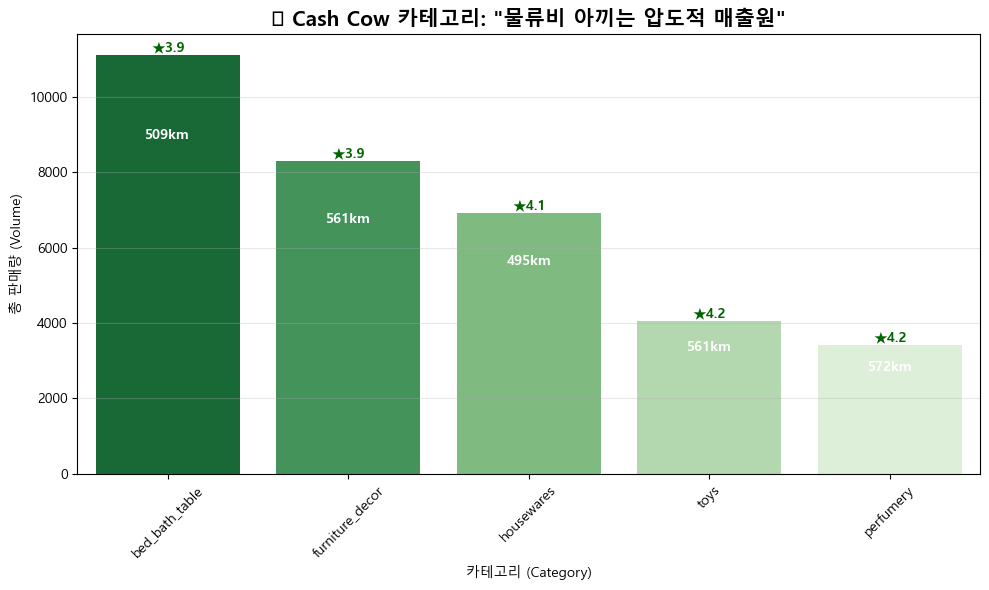

In [7]:
# === Cash Cow (근거리) 카테고리 TOP 5 ===

# 1. 상세 표 출력
print("\n" + "="*60)
print(f"💰 [Cash Cow] 가까워서 배송비 아끼는 효자 카테고리 TOP 5")
print("="*60)
print(cash_cow_cat_5[['Category', 'Volume', 'Distance', 'Score', 'Price']].to_string(index=False))
print("-" * 60 + "\n")

# 2. 시각화
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=cash_cow_cat_5, x='Category', y='Volume', palette='Greens_r', ax=ax)

# 라벨링 (거리 + 평점 표시)
for i, p in enumerate(ax.patches):
    if i < len(cash_cow_cat_5):
        height = p.get_height()
        dist = cash_cow_cat_5['Distance'].iloc[i]
        score = cash_cow_cat_5['Score'].iloc[i]
        
        # 막대 위: 평점
        ax.text(p.get_x() + p.get_width()/2., height + 100, f"★{score:.1f}", 
                ha="center", fontsize=10, fontweight='bold', color='darkgreen')
        
        # 막대 안: 거리
        ax.text(p.get_x() + p.get_width()/2., height - (height*0.2), f"{int(dist)}km", 
                ha="center", fontsize=10, fontweight='bold', color='white')

ax.set_title('💰 Cash Cow 카테고리: "물류비 아끼는 압도적 매출원"', fontsize=15, fontweight='bold')
ax.set_ylabel('총 판매량 (Volume)')
ax.set_xlabel('카테고리 (Category)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()